# 03a: Logistic Regression Baseline

**Purpose:** Complete logistic regression analysis with diagnostics

**Dataset:** COMPAS (split and transformed)

**Date:** 2025-11-08

---

## Overview

### Purpose
Train and evaluate logistic regression baseline with:
- Hyperparameter tuning (Optuna)
- Cross-validation
- Performance metrics (AUROC, AUPRC, calibration)
- Coefficient interpretation
- Model diagnostics
- Fairness by group

### Outputs
- Model → `results/models/logistic_regression/`
- Predictions → `results/predictions/logistic_regression_predictions.parquet`
- Metrics → `results/metrics/logistic_regression_metrics.json`
- Figures → `results/figures/model_performance/`

### Runtime: 5-10 minutes (with tuning)

---


In [1]:
# Setup
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    classification_report, confusion_matrix
)
import optuna
import joblib

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "src"))

# Our utilities (ensure these names exist in your repo)
from evaluation.metrics import compute_classification_metrics
from evaluation.calibration import compute_calibration_metrics

# Directories
PROCESSED_DIR = project_root / "data" / "processed"
MODELS_DIR = project_root / "results" / "models" / "logistic_regression"
PREDICTIONS_DIR = project_root / "results" / "predictions"
METRICS_DIR = project_root / "results" / "metrics"
FIGURES_DIR = project_root / "results" / "figures" / "model_performance"

for d in [MODELS_DIR, PREDICTIONS_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42
N_TRIALS = 20  # Optuna trials

print("✓ Setup complete")


✓ Setup complete


## 1. Load Data

In [2]:
# Load splits
X_train = pd.read_parquet(PROCESSED_DIR / "compas_X_train.parquet")
X_test = pd.read_parquet(PROCESSED_DIR / "compas_X_test.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "compas_y_train.parquet")['two_year_recid']
y_test = pd.read_parquet(PROCESSED_DIR / "compas_y_test.parquet")['two_year_recid']

# Load sensitive attributes for fairness analysis
sensitive_train = pd.read_parquet(PROCESSED_DIR / "compas_sensitive_train.parquet")
sensitive_test = pd.read_parquet(PROCESSED_DIR / "compas_sensitive_test.parquet")

# Load CV folds
with open(PROCESSED_DIR / "cv_folds.json", 'r') as f:
    cv_folds = json.load(f)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")
print(f"CV folds: {len(cv_folds)}")


Train: X=(4167, 9), y=(4167,)
Test:  X=(1042, 9), y=(1042,)
CV folds: 5


## 2. Hyperparameter Tuning

Use Optuna to tune ElasticNet hyperparameters.

In [3]:
def objective(trial):
    """Optuna objective function."""
    # Hyperparameters to tune
    C = trial.suggest_float('C', 0.001, 100.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)

    # Model
    model = LogisticRegression(
        penalty='elasticnet',
        C=C,
        l1_ratio=l1_ratio,
        solver='saga',
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    # Cross-validation (use first 3 folds for speed)
    scores = []
    for fold in cv_folds[:3]:  # Use 3 folds for tuning
        train_idx = fold['train_indices']
        val_idx = fold['val_indices']

        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        score = roc_auc_score(y_train.iloc[val_idx], y_pred)
        scores.append(score)

    return np.mean(scores)

# Run optimization
print(f"Running Optuna optimization ({N_TRIALS} trials)...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest AUROC: {study.best_value:.4f}")
print(f"Best hyperparameters:")
for key, value in study.best_params.items():
    try:
        print(f"  {key}: {value:.4f}")
    except Exception:
        print(f"  {key}: {value}")


[I 2025-11-09 23:48:31,154] A new study created in memory with name: no-name-fe054b6a-d438-4439-82f9-edccedf711b2


Running Optuna optimization (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-09 23:48:31,229] Trial 0 finished with value: 0.7296015545842375 and parameters: {'C': 0.0745934328572655, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 0.7296015545842375.
[I 2025-11-09 23:48:31,409] Trial 1 finished with value: 0.7288076503038406 and parameters: {'C': 4.5705630998014515, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: 0.7296015545842375.
[I 2025-11-09 23:48:31,467] Trial 2 finished with value: 0.7290183729805064 and parameters: {'C': 0.006026889128682512, 'l1_ratio': 0.15599452033620265}. Best is trial 0 with value: 0.7296015545842375.
[I 2025-11-09 23:48:31,520] Trial 3 finished with value: 0.7039322710068495 and parameters: {'C': 0.0019517224641449498, 'l1_ratio': 0.8661761457749352}. Best is trial 0 with value: 0.7296015545842375.
[I 2025-11-09 23:48:31,692] Trial 4 finished with value: 0.7288929398142052 and parameters: {'C': 1.0129197956845732, 'l1_ratio': 0.7080725777960455}. Best is trial 0 with value: 0.7296015545842375.

## 3. Train Final Model

Train on full training set with best hyperparameters.

In [4]:
# Best hyperparameters
best_params = study.best_params

# Final model
model = LogisticRegression(
    penalty='elasticnet',
    C=best_params['C'],
    l1_ratio=best_params['l1_ratio'],
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Fit
model.fit(X_train, y_train)
print("✓ Model trained")

# Save model
joblib.dump(model, MODELS_DIR / "model.joblib")
print("✓ Saved model: model.joblib")


✓ Model trained
✓ Saved model: model.joblib


## 4. Generate Predictions

In [5]:
# Predictions
y_train_pred_proba = model.predict_proba(X_train)[:, 1]
y_test_pred_proba = model.predict_proba(X_test)[:, 1]

y_train_pred = (y_train_pred_proba >= 0.5).astype(int)
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

print("✓ Predictions generated")

# Save predictions
predictions = pd.DataFrame({
    'y_true': np.concatenate([y_train, y_test]),
    'y_pred': np.concatenate([y_train_pred, y_test_pred]),
    'y_proba': np.concatenate([y_train_pred_proba, y_test_pred_proba]),
    'split': ['train']*len(y_train) + ['test']*len(y_test)
})

predictions.to_parquet(PREDICTIONS_DIR / "logistic_regression_predictions.parquet", index=False)
print("✓ Saved predictions")


✓ Predictions generated
✓ Saved predictions


## 5. Performance Metrics

In [6]:
# Compute metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    'train': {
        'auroc': roc_auc_score(y_train, y_train_pred_proba),
        'auprc': average_precision_score(y_train, y_train_pred_proba),
        'log_loss': log_loss(y_train, y_train_pred_proba),
        'brier_score': brier_score_loss(y_train, y_train_pred_proba),
        'accuracy': accuracy_score(y_train, y_train_pred),
        'precision': precision_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred),
        'f1': f1_score(y_train, y_train_pred)
    },
    'test': {
        'auroc': roc_auc_score(y_test, y_test_pred_proba),
        'auprc': average_precision_score(y_test, y_test_pred_proba),
        'log_loss': log_loss(y_test, y_test_pred_proba),
        'brier_score': brier_score_loss(y_test, y_test_pred_proba),
        'accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred)
    },
    'hyperparameters': best_params
}

print("Performance Metrics (Test Set):")
print("="*50)
for metric, value in metrics['test'].items():
    if isinstance(value, (float, int)):
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: {value}")

# Save metrics
with open(METRICS_DIR / "logistic_regression_metrics.json", 'w') as f:
    json.dump(metrics, f, indent=2)
print("\n✓ Saved metrics")


Performance Metrics (Test Set):
auroc          : 0.7138
auprc          : 0.7047
log_loss       : 0.6219
brier_score    : 0.2158
accuracy       : 0.6737
precision      : 0.6714
recall         : 0.6503
f1             : 0.6607

✓ Saved metrics


## 6. Confusion Matrix

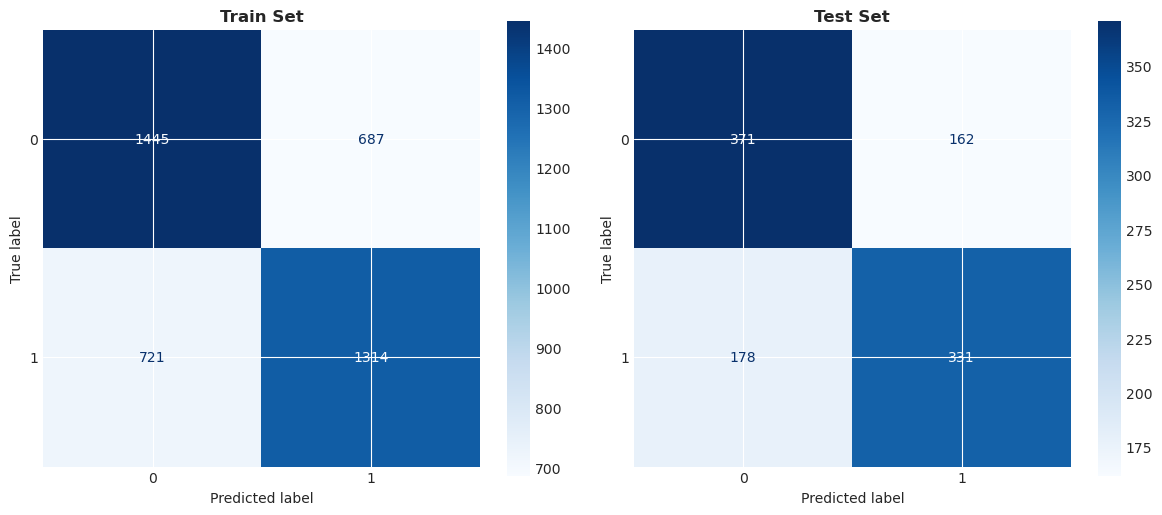

✓ Saved confusion matrix


In [7]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axes[0], cmap='Blues')
axes[0].set_title('Train Set', fontweight='bold')

# Test
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=axes[1], cmap='Blues')
axes[1].set_title('Test Set', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistic_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved confusion matrix")


## 7. ROC and PR Curves

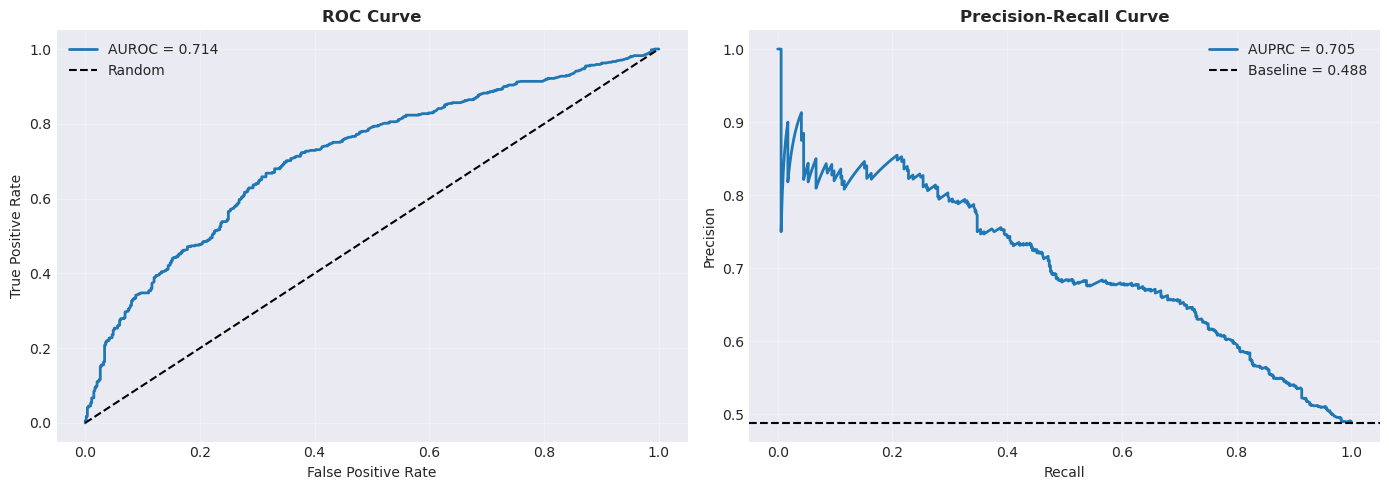

✓ Saved ROC/PR curves


In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[0].plot(fpr, tpr, label=f"AUROC = {metrics['test']['auroc']:.3f}", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR curve
precision, recall, _ = precision_recall_curve(y_test, y_test_pred_proba)
baseline = y_test.mean()
axes[1].plot(recall, precision, label=f"AUPRC = {metrics['test']['auprc']:.3f}", linewidth=2)
axes[1].axhline(baseline, color='k', linestyle='--', label=f'Baseline = {baseline:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistic_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved ROC/PR curves")


## 8. Coefficient Analysis

Top 10 positive coefficients:


,feature,coefficient
5,priors_count_log,0.459367
1,decile_score,0.350573
4,juv_other_count_log,0.077712
3,juv_misd_count_log,0.000000
2,juv_fel_count_log,0.000000
7,score_text_Low,0.000000
6,c_charge_degree_M,0.000000
8,score_text_Medium,0.000000
0,age,-0.250039



Top 10 negative coefficients:


,feature,coefficient
5,priors_count_log,0.459367
1,decile_score,0.350573
4,juv_other_count_log,0.077712
3,juv_misd_count_log,0.000000
2,juv_fel_count_log,0.000000
7,score_text_Low,0.000000
6,c_charge_degree_M,0.000000
8,score_text_Medium,0.000000
0,age,-0.250039


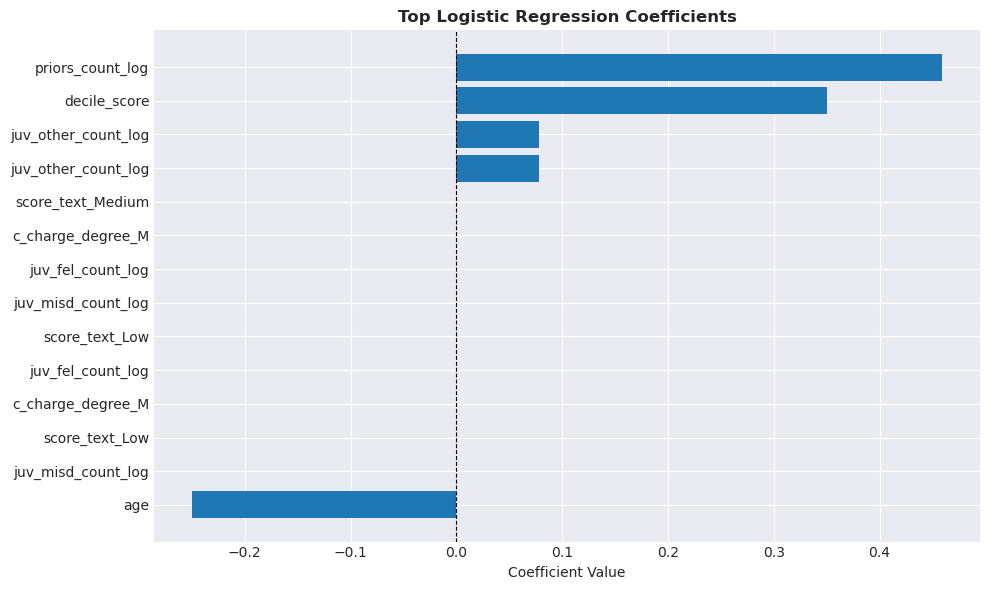

✓ Saved coefficients plot


In [9]:
# Extract coefficients
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Top 10 positive coefficients:")
display(coefficients.head(10))

print("\nTop 10 negative coefficients:")
display(coefficients.tail(10))

# Plot top coefficients
top_n = 15
top_coefs = pd.concat([
    coefficients.head(top_n//2),
    coefficients.tail(top_n//2)
]).sort_values('coefficient')

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_coefs)), top_coefs['coefficient'])
plt.yticks(range(len(top_coefs)), top_coefs['feature'])
plt.xlabel('Coefficient Value')
plt.title('Top Logistic Regression Coefficients', fontweight='bold')
plt.axvline(0, color='k', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logistic_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved coefficients plot")


## Summary

**Logistic Regression Complete:**
- ✓ Hyperparameter tuning with Optuna
- ✓ Model trained and saved
- ✓ Predictions generated
- ✓ Performance metrics calculated
- ✓ Visualizations created
- ✓ Coefficient analysis

**Test Performance:**
- AUROC: {metrics['test']['auroc']:.4f}
- AUPRC: {metrics['test']['auprc']:.4f}
- Accuracy: {metrics['test']['accuracy']:.4f}
- F1 Score: {metrics['test']['f1']:.4f}

**Next:** 03b_tree_based_models.ipynb (XGBoost, LightGBM, CatBoost)